In [1]:
import warnings 
warnings.filterwarnings('ignore')

## K-Nearest-Neighbors

KNN falls in the supervised learning family of algorithms. Informally, this means that we are given a labelled dataset consiting of training observations (x,y) and would like to capture the relationship between x and y. More formally, our goal is to learn a function h:X→Y so that given an unseen observation x, h(x) can confidently predict the corresponding output y.

In this module we will explore the inner workings of KNN, choosing the optimal K values and using KNN from scikit-learn.

## Overview

1.Read the problem statement.

2.Get the dataset.

3.Explore the dataset.

4.Pre-processing of dataset.

5.Visualization

6.Transform the dataset for building machine learning model.

7.Split data into train, test set.

7.Build Model.

8.Apply the model.

9.Evaluate the model.

10.Finding Optimal K value

11.Repeat 7,8,9 steps.

## Problem statement

### Dataset

The data set we’ll be using is the Iris Flower Dataset which was first introduced in 1936 by the famous statistician Ronald Fisher and consists of 50 observations from each of three species of Iris (Iris setosa, Iris virginica and Iris versicolor). Four features were measured from each sample: the length and the width of the sepals and petals.

**Attributes of the dataset:** https://archive.ics.uci.edu/ml/datasets/Iris

**Train the KNN algorithm to be able to distinguish the species from one another given the measurements of the 4 features.**

## Question 1

Import the data set and print 10 random rows from the data set

In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc

In [3]:
colnames = ['sepal length in cm', 'sepal width in cm', 'petal length in cm', 'petal width in cm', 'species']
iris = pd.read_csv("iris.data", names= colnames)
iris.head()

,sepal length in cm,sepal width in cm,petal length in cm,petal width in cm,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Data Pre-processing

## Question 2 - Estimating missing values

*Its not good to remove the records having missing values all the time. We may end up loosing some data points. So, we will have to see how to replace those missing values with some estimated values (median) *

In [4]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
sepal length in cm    150 non-null float64
sepal width in cm     150 non-null float64
petal length in cm    150 non-null float64
petal width in cm     150 non-null float64
species               150 non-null object
dtypes: float64(4), object(1)
memory usage: 5.9+ KB


In [5]:
iris.dtypes

sepal length in cm    float64
sepal width in cm     float64
petal length in cm    float64
petal width in cm     float64
species                object
dtype: object

In [6]:
medSepLen = iris['sepal length in cm'].median(skipna=True)
medSepWid = iris['sepal width in cm'].median(skipna=True)
medPetLen = iris['petal length in cm'].median(skipna=True)
medPetWid = iris['petal width in cm'].median(skipna=True)
iris['sepal length in cm']=iris['sepal length in cm'].mask(iris['sepal length in cm'] == 0,medSepLen)
iris['sepal width in cm']=iris['sepal width in cm'].mask(iris['sepal width in cm'] == 0,medSepWid)
iris['petal length in cm']=iris['sepal length in cm'].mask(iris['sepal length in cm'] == 0,medPetLen)
iris['petal width in cm']=iris['petal width in cm'].mask(iris['petal width in cm'] == 0,medPetWid)

## Question 3 - Dealing with categorical data

Change all the classes to numericals (0to2).

In [7]:
iris.species.replace(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], [0, 1, 2], inplace=True)

## Question 4

*Observe the association of each independent variable with target variable and drop variables from feature set having correlation in range -0.1 to 0.1 with target variable.*

In [8]:
iris.corr()
#Nothing lies in the range of -0.1 & +0.1 least value -0.109 is lesser than -0.1

,sepal length in cm,sepal width in cm,petal length in cm,petal width in cm,species
sepal length in cm,1.000000,-0.109369,1.000000,0.817954,0.782561
sepal width in cm,-0.109369,1.000000,-0.109369,-0.356544,-0.419446
petal length in cm,1.000000,-0.109369,1.000000,0.817954,0.782561
petal width in cm,0.817954,-0.356544,0.817954,1.000000,0.956464
species,0.782561,-0.419446,0.782561,0.956464,1.000000


## Question 5

*Observe the independent variables variance and drop such variables having no variance or almost zero variance(variance < 0.1). They will be having almost no influence on the classification.*

In [9]:
iris.var()

sepal length in cm    0.685694
sepal width in cm     0.188004
petal length in cm    0.685694
petal width in cm     0.582414
species               0.671141
dtype: float64

## Question 6

*Plot the scatter matrix for all the variables.*

In [10]:
# scatter plot matrix
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
scatter_matrix(iris)
plt.show()

<Figure size 640x480 with 25 Axes>

## Split the dataset into training and test sets

## Question 7

*Split the dataset into training and test sets with 80-20 ratio.*

In [11]:
# Split-out validation dataset
from sklearn import model_selection
array = iris.values
X = array[:,0:4]
Y = array[:,4]
validation_size = 0.20
seed = 7
xtrain, xtest, ytrain, ytest = model_selection.train_test_split(X, Y, test_size=validation_size, random_state=seed)

## Question 8 - Model

*Build the model and train and test on training and test sets respectively using **scikit-learn**. Print the Accuracy of the model with different values of **k=3,5,9**.*

**Hint:** For accuracy you can check **accuracy_score()** in scikit-learn

In [12]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X, Y)
ypred = knn.predict(X)
print(metrics.accuracy_score(Y, ypred))
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X, Y)
ypred = knn.predict(X)
print(metrics.accuracy_score(Y, ypred))
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X, Y)
ypred = knn.predict(X)
print(metrics.accuracy_score(Y, ypred))

0.9733333333333334
0.96
0.9533333333333334


## Question 9 - Cross Validation

Run the KNN with no of neighbours to be 1,3,5..19 and *Find the **optimal number of neighbours** from the above list using the Mis classification error

Hint:

Misclassification error (MSE) = 1 - Test accuracy score. Calculated MSE for each model with neighbours = 1,3,5...19 and find the model with lowest MSE

In [13]:
XAxis = [1,3,5,7,9,11,13,15,17,19]
YAxis = [0,0,0,0,0,0,0,0,0,0]

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X, Y)
ypred = knn.predict(X)
YAxis[0] = (1-(metrics.accuracy_score(Y, ypred)))
print(YAxis[0])

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X, Y)
ypred = knn.predict(X)
YAxis[1] = (1-(metrics.accuracy_score(Y, ypred)))
print(YAxis[1])

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X, Y)
ypred = knn.predict(X)
YAxis[2] = (1-(metrics.accuracy_score(Y, ypred)))
print(YAxis[2])

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X, Y)
ypred = knn.predict(X)
YAxis[3] = (1-(metrics.accuracy_score(Y, ypred)))
print(YAxis[3])

knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X, Y)
ypred = knn.predict(X)
YAxis[3] = (1-(metrics.accuracy_score(Y, ypred)))
print(YAxis[3])

knn = KNeighborsClassifier(n_neighbors=11)
knn.fit(X, Y)
ypred = knn.predict(X)
YAxis[4] = (1-(metrics.accuracy_score(Y, ypred)))
print(YAxis[4])

knn = KNeighborsClassifier(n_neighbors=13)
knn.fit(X, Y)
ypred = knn.predict(X)
YAxis[5] = (1-(metrics.accuracy_score(Y, ypred)))
print(YAxis[5])

knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X, Y)
ypred = knn.predict(X)
YAxis[6] = (1-(metrics.accuracy_score(Y, ypred)))
print(YAxis[6])

knn = KNeighborsClassifier(n_neighbors=17)
knn.fit(X, Y)
ypred = knn.predict(X)
YAxis[7] = (1-(metrics.accuracy_score(Y, ypred)))
print(YAxis[7])

knn = KNeighborsClassifier(n_neighbors=19)
knn.fit(X, Y)
ypred = knn.predict(X)
YAxis[8] = (1-(metrics.accuracy_score(Y, ypred)))
print(YAxis[8])

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X, Y)
ypred = knn.predict(X)
print('The least MSE value is k value is 3', (1-(metrics.accuracy_score(Y, ypred))))

0.0
0.026666666666666616
0.040000000000000036
0.040000000000000036
0.046666666666666634
0.033333333333333326
0.040000000000000036
0.046666666666666634
0.053333333333333344
0.046666666666666634
('The least MSE value is k value is 3', 0.026666666666666616)


In [14]:
YAxis

[0.0,
 0.026666666666666616,
 0.040000000000000036,
 0.046666666666666634,
 0.033333333333333326,
 0.040000000000000036,
 0.046666666666666634,
 0.053333333333333344,
 0.046666666666666634,
 0]

## Question 10

*Plot misclassification error vs k (with k value on X-axis) using matplotlib.*

Text(0,0.5,'Misclassification Error')

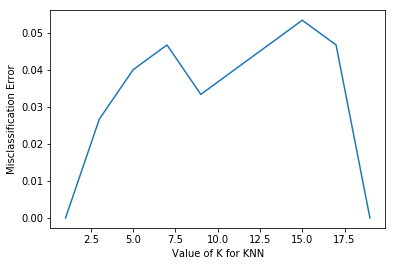

In [15]:
# import Matplotlib (scientific plotting library)
import matplotlib.pyplot as plt

# allow plots to appear within the notebook
%matplotlib inline

# plot the relationship between K and testing accuracy
# plt.plot(x_axis, y_axis)
plt.plot(XAxis, YAxis)
plt.xlabel('Value of K for KNN')
plt.ylabel('Misclassification Error')

# Naive Bayes with Iris Data

In [16]:
#Load all required library
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB

### Slice  Iris data set for Independent variables and dependent variables
#### Please note 'Species' is my dependent variables, name it y and independent set data as X

In [17]:
#Replace Species type with numbers
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.naive_bayes import GaussianNB
from sklearn import model_selection
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
array = iris.values
X = array[:,0:4]
y = array[:,4]

In [18]:
#Check the dataset
print(y)
print(X)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2.]
[[5.1 3.5 5.1 0.2]
 [4.9 3.  4.9 0.2]
 [4.7 3.2 4.7 0.2]
 [4.6 3.1 4.6 0.2]
 [5.  3.6 5.  0.2]
 [5.4 3.9 5.4 0.4]
 [4.6 3.4 4.6 0.3]
 [5.  3.4 5.  0.2]
 [4.4 2.9 4.4 0.2]
 [4.9 3.1 4.9 0.1]
 [5.4 3.7 5.4 0.2]
 [4.8 3.4 4.8 0.2]
 [4.8 3.  4.8 0.1]
 [4.3 3.  4.3 0.1]
 [5.8 4.  5.8 0.2]
 [5.7 4.4 5.7 0.4]
 [5.4 3.9 5.4 0.4]
 [5.1 3.5 5.1 0.3]
 [5.7 3.8 5.7 0.3]
 [5.1 3.8 5.1 0.3]
 [5.4 3.4 5.4 0.2]
 [5.1 3.7 5.1 0.4]
 [4.6 3.6 4.6 0.2]
 [5.1 3.3 5.1 0.5]
 [4.8 3.4 4.8 0.2]
 [5.  3.  5.  0.2]
 [5.  3.4 5.  0.4]
 [5.2 3.5 5.2 0.2]
 [5.2 3.4 

# Question 11 
Find the distribution of target variable (Class)

And, Plot the distribution of target variable using histogram

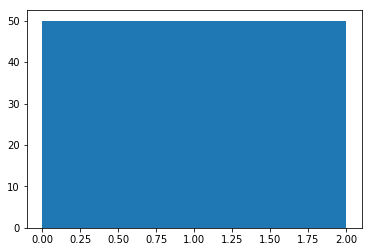

In [19]:
import matplotlib.pyplot as plt
plt.hist(y, bins=3)
plt.show()

In [20]:
iris.head()

,sepal length in cm,sepal width in cm,petal length in cm,petal width in cm,species
0,5.1,3.5,5.1,0.2,0
1,4.9,3.0,4.9,0.2,0
2,4.7,3.2,4.7,0.2,0
3,4.6,3.1,4.6,0.2,0
4,5.0,3.6,5.0,0.2,0


In [313]:
#Drop Id variable from data
iris.set_index('sepal length in cm', inplace=True)
iris.head()

,sepal width in cm,petal length in cm,petal width in cm,species
sepal length in cm,,,,
5.1,3.5,5.1,0.2,0
4.9,3.0,4.9,0.2,0
4.7,3.2,4.7,0.2,0
4.6,3.1,4.6,0.2,0
5.0,3.6,5.0,0.2,0


### Question 12 
Find Correlation among all variables and give your insights 

In [21]:
#Please note, it's Require to remove correlated features because they are voted twice in the model and 
## it can lead to over inflating importance.We will ignore it here

In [22]:
iris.corr()

,sepal length in cm,sepal width in cm,petal length in cm,petal width in cm,species
sepal length in cm,1.000000,-0.109369,1.000000,0.817954,0.782561
sepal width in cm,-0.109369,1.000000,-0.109369,-0.356544,-0.419446
petal length in cm,1.000000,-0.109369,1.000000,0.817954,0.782561
petal width in cm,0.817954,-0.356544,0.817954,1.000000,0.956464
species,0.782561,-0.419446,0.782561,0.956464,1.000000


### Split data in Training and test set in 80:20.

In [23]:
array = iris.values
X = array[:,0:4]
Y = array[:,4]
validation_size = 0.20

### Question 13 
Do Feature Scaling 

In [286]:
# Use StandardScaler or similar methods

In [24]:
from sklearn.preprocessing import StandardScaler
scaled_features = iris.copy()
colnames = ['sepal length in cm', 'sepal width in cm', 'petal length in cm', 'petal width in cm', 'species']
features = scaled_features[colnames]
scaler = StandardScaler().fit(features.values)
features = scaler.transform(features.values)
scaled_features[colnames] = features
print(scaled_features)

     sepal length in cm  sepal width in cm  petal length in cm  \
0             -0.900681           1.032057           -0.900681   
1             -1.143017          -0.124958           -1.143017   
2             -1.385353           0.337848           -1.385353   
3             -1.506521           0.106445           -1.506521   
4             -1.021849           1.263460           -1.021849   
5             -0.537178           1.957669           -0.537178   
6             -1.506521           0.800654           -1.506521   
7             -1.021849           0.800654           -1.021849   
8             -1.748856          -0.356361           -1.748856   
9             -1.143017           0.106445           -1.143017   
10            -0.537178           1.494863           -0.537178   
11            -1.264185           0.800654           -1.264185   
12            -1.264185          -0.124958           -1.264185   
13            -1.870024          -0.124958           -1.870024   
14        

### Question 14 
Train and Fit NaiveBayes Model

In [28]:
#Fit the model
array = iris.values
X = array[:,0:4]
Y = array[:,4]
validation_size = 0.20 #80% For train & 20% for test / validation.
seed = 7
xtrain, xtest, ytrain, ytest = model_selection.train_test_split(X, Y, test_size=validation_size, random_state=seed)
#Initialize Gaussian Naive Bayes
model = GaussianNB()
# Test options and evaluation metric
scoring = 'accuracy'
#Fitting the training set
model.fit(xtrain, ytrain)

GaussianNB(priors=None, var_smoothing=1e-09)

In [31]:
#Predict
#Prediction Probability
predicted = model.predict(xtest)

array([[7, 0, 0],
       [0, 9, 2],
       [0, 3, 9]], dtype=int64)

In [32]:
model_score = model.score(xtest, ytest)
model_score

0.8333333333333334

In [44]:
y_predictProb = model.predict_proba(xtest)
y_predictProb

array([[3.88223946e-046, 1.34217114e-001, 8.65782886e-001],
       [8.60041272e-029, 9.95100975e-001, 4.89902500e-003],
       [1.00000000e+000, 1.45047205e-010, 4.16709859e-016],
       [1.08234680e-029, 9.90322658e-001, 9.67734203e-003],
       [1.50550773e-037, 9.92684149e-001, 7.31585070e-003],
       [9.99999963e-001, 3.68701287e-008, 8.41262005e-016],
       [2.09624690e-039, 1.41592641e-001, 8.58407359e-001],
       [2.30784335e-022, 9.99770126e-001, 2.29874379e-004],
       [1.00000000e+000, 4.17804430e-012, 7.64914290e-018],
       [3.12750774e-034, 6.42690898e-001, 3.57309102e-001],
       [8.47625684e-048, 2.25305091e-002, 9.77469491e-001],
       [2.54735575e-035, 5.50657995e-001, 4.49342005e-001],
       [1.00000000e+000, 8.77147239e-015, 5.52317588e-019],
       [8.15377524e-107, 5.75395594e-013, 1.00000000e+000],
       [1.00000000e+000, 5.42443817e-011, 2.78068911e-016],
       [9.02835334e-046, 7.72665796e-002, 9.22733420e-001],
       [3.72641205e-054, 1.61277396e-002

### Question 15 
Print Accuracy and Confusion Matrix and Conclude your findings

In [37]:
# show Confusion Matrix
metrics.confusion_matrix(predicted, ytest)

array([[7, 0, 0],
       [0, 9, 2],
       [0, 3, 9]], dtype=int64)

In [50]:
optimalF1 = 0
optimalTh = 0

In [49]:
for th in thresholds:
    preds = np.where(model.predict_proba(X_test)[:,1] > th, 1, 0)
    f1Score = f1_score(y_test, preds)
    if(optimalF1 < f1Score):
        optimalF1 = f1Score
        optimalTh = th

NameError: name 'thresholds' is not defined

In [48]:
# show accuracy
# calculate accuracy measures and confusion matrix
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc, roc_curve
pd.DataFrame(data=[accuracy_score(ytest, preds), 
                   recall_score(ytest, preds),
                   precision_score(ytest, preds),
                   f1_score(ytest, preds)], 
             index=["accuracy", "recall", "precision", "f1Score"])

NameError: name 'preds' is not defined

In [0]:
#Show precision and Recall metrics

# For Practice  - Optional

All the questions from 16 to 20 are for practice.

# Using SVM with Diebetes Dataset

In [0]:
#Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Question 16 
Read the input file 'Diabetes.csv' using Pandas and check it's column names.

Check dimension of dataset.

Check distribution of dependent variable, Outcome and plot it.


In [0]:
# Eye ball the imported dataset

### Out of  768 data points, 500 are labeled as 0 and 268 as 1.
### Outcome 0 means No diabetes, outcome 1 means diabetes

In [0]:
# Check data types and info of dataset

# Question 17 
Check data distribution using summary statistics and provide your findings.

Do correlation analysis and bivariate viualization with Insights


# Question 18 
Do train and test split. 
Optionally - You can do with stratify sampling(optional) on Outcome variable to maintain the distribution of dependent variable

# Question 19 
Train Support Vector Machine Model(1 Marks)

In [0]:
# use from sklearn.svm import SVC

In [0]:
# your insights

# Question 20
Scale the data points using MinMaxScaler

Fit SVM Model on Scale data and give your observation

#we can try increasing either C or gamma to fit a more complex model.

# Optional Question - 
Try improving the model accuracy using C=1000 (1 Marks)

### Here, increasing C allows us to improve the model, resulting in ??? accuracy.
### Let's try to explore different Kernel and C (Bonus for practice)

In [0]:
import multiprocessing 
from sklearn.model_selection import GridSearchCV

In [0]:
 param_grid = [    {        
     'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],        
     'C': [ 0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0 ]    } ]

In [0]:
gs = GridSearchCV(estimator=SVC(), param_grid=param_grid,scoring='accuracy', cv=10, n_jobs=multiprocessing.cpu_count())

In [0]:
gs.fit(X_train_scaled, y_train) 

GridSearchCV(cv=10, error_score='raise',
       estimator=SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape=None, degree=3, gamma='auto', kernel='rbf',
  max_iter=-1, probability=False, random_state=None, shrinking=True,
  tol=0.001, verbose=False),
       fit_params={}, iid=True, n_jobs=4,
       param_grid=[{'kernel': ['linear', 'rbf', 'poly', 'sigmoid'], 'C': [0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0]}],
       pre_dispatch='2*n_jobs', refit=True, return_train_score=True,
       scoring='accuracy', verbose=0)

In [0]:
gs.best_estimator_

SVC(C=2.5, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape=None, degree=3, gamma='auto', kernel='linear',
  max_iter=-1, probability=False, random_state=None, shrinking=True,
  tol=0.001, verbose=False)

In [0]:
gs.best_score_ 

0.77777777777777779